## Business Case context – Customer Behavior & Segmentation

The sections below provide monthly revenue trends, top categories, and customer segmentation/tenure; additional RFM and geographic breakdowns can be layered on these same BigQuery tables if needed.

In [1]:
import os
import sys

import pandas as pd
import pandas_gbq
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from config import BQ_PROJECT, BQ_DATASET_DW

def bq_table(name):
    return f"`{BQ_PROJECT}.{BQ_DATASET_DW}.{name}`"

plt.style.use('ggplot')
sns.set_palette('husl')

/home/teoyongsong/miniconda3/envs/olist-bq/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 1. Monthly sales trends

In [2]:
query_monthly = f"""
SELECT
    DATE_TRUNC(order_date_key, MONTH) AS month,
    SUM(total_item_value) AS revenue,
    COUNT(DISTINCT order_id) AS orders,
    COUNT(*) AS items_sold
FROM {bq_table('fact_order_items')}
GROUP BY 1
ORDER BY 1
"""
df_monthly = pandas_gbq.read_gbq(query_monthly, project_id=BQ_PROJECT)
df_monthly["month"] = pd.to_datetime(df_monthly["month"])
df_monthly.head(10)

Downloading: 100%|██████████|


,month,revenue,orders,items_sold
0,2016-09-01,354.750000000,3,6
1,2016-10-01,56808.840000000,308,363
2,2016-12-01,19.620000000,1,1
3,2017-01-01,137188.490000000,789,955
4,2017-02-01,286280.620000000,1733,1951
5,2017-03-01,432048.590000000,2641,3000
6,2017-04-01,412422.240000000,2391,2684
7,2017-05-01,586190.950000000,3660,4136
8,2017-06-01,502963.040000000,3217,3583
9,2017-07-01,584971.620000000,3969,4519


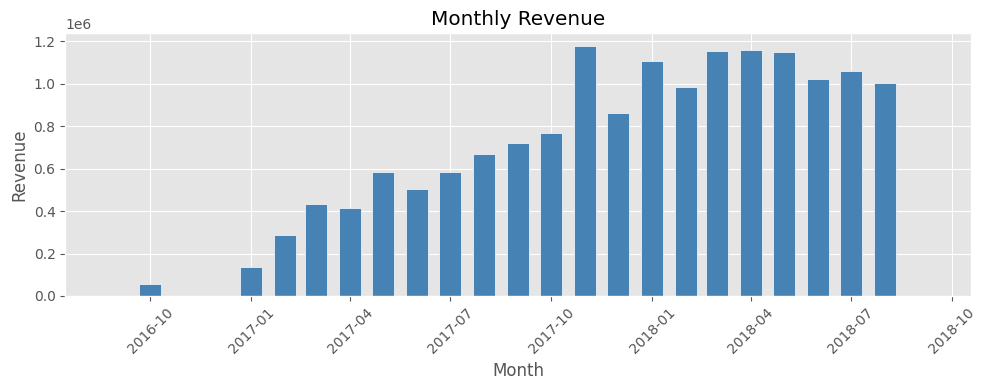

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_monthly["month"], df_monthly["revenue"], width=20, color='steelblue', edgecolor='white')
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Top-selling product categories

In [4]:
query_top = f"""
SELECT
    COALESCE(p.product_category_name, 'Unknown') AS category,
    SUM(f.total_item_value) AS revenue,
    COUNT(*) AS items_sold
FROM {bq_table('fact_order_items')} f
LEFT JOIN {bq_table('dim_product')} p ON p.product_key = f.product_key
GROUP BY 1
ORDER BY revenue DESC
LIMIT 15
"""
df_top = pandas_gbq.read_gbq(query_top, project_id=BQ_PROJECT)
df_top

Downloading: 100%|██████████|


,category,revenue,items_sold
0,beleza_saude,1441248.070000000,9670
1,relogios_presentes,1305541.610000000,5991
2,cama_mesa_banho,1241681.720000000,11115
3,esporte_lazer,1156656.480000000,8641
4,informatica_acessorios,1059272.400000000,7827
5,moveis_decoracao,902511.790000000,8334
6,utilidades_domesticas,778397.770000000,6964
7,cool_stuff,719329.950000000,3796
8,automotivo,685384.320000000,4235
9,ferramentas_jardim,584219.210000000,4347


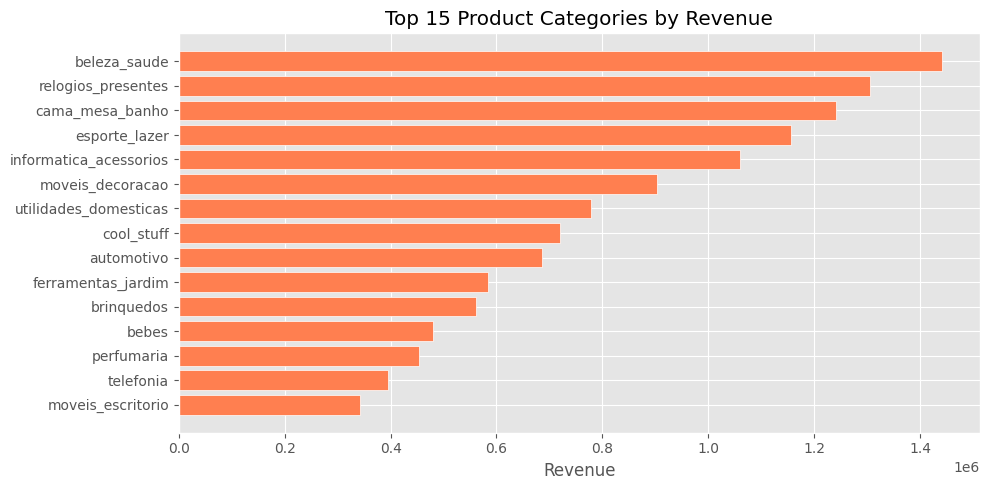

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_top["category"].iloc[::-1], df_top["revenue"].iloc[::-1], color='coral', edgecolor='white')
ax.set_title("Top 15 Product Categories by Revenue")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.show()

## 3. Customer behavior & segmentation (tenure / CLV proxy)

In [ ]:
query_seg = f"""
SELECT
    tenure_segment,
    COUNT(*) AS customers,
    SUM(total_revenue) AS total_revenue,
    ROUND(AVG(total_revenue), 2) AS avg_revenue_per_customer
FROM {bq_table('dim_customer')}
GROUP BY tenure_segment
ORDER BY total_revenue DESC
"""
df_seg = pandas_gbq.read_gbq(query_seg, project_id=BQ_PROJECT)
df_seg

Downloading: 100%|██████████|


,tenure_segment,customers,total_revenue,avg_revenue_per_customer
0,Established,59246,9438573.230000000,159.310000000
1,Loyal,29974,4790487.930000000,159.820000000
2,New,10221,1614492.080000000,157.960000000


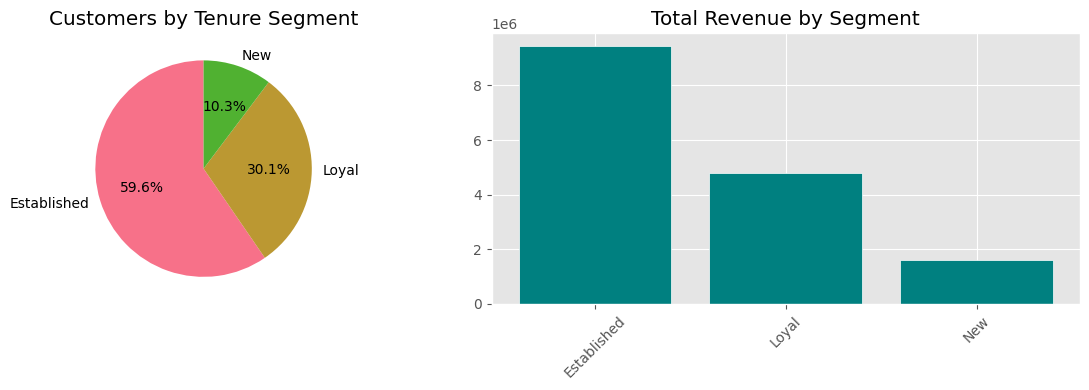

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(df_seg["customers"], labels=df_seg["tenure_segment"], autopct='%1.1f%%', startangle=90)
axes[0].set_title("Customers by Tenure Segment")
axes[1].bar(df_seg["tenure_segment"], df_seg["total_revenue"], color='teal', edgecolor='white')
axes[1].set_title("Total Revenue by Segment")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Late delivery rate

In [ ]:
query_late = f"""
SELECT
    is_late_delivery,
    COUNT(*) AS items,
    SUM(total_item_value) AS revenue
FROM {bq_table('fact_order_items')}
WHERE delivery_date_key IS NOT NULL
GROUP BY is_late_delivery
"""
df_late = pandas_gbq.read_gbq(query_late, project_id=BQ_PROJECT)
total = df_late["items"].sum()
late_pct = df_late.loc[df_late["is_late_delivery"] == True, "items"].sum() / total * 100 if total else 0
print(f"Late delivery rate (by items): {late_pct:.1f}%")
df_late

Downloading: 100%|██████████|
Late delivery rate (by items): 6.6%


,is_late_delivery,items,revenue
0,False,102931,14268207.190000000
1,True,7265,1150936.220000000
